In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# NLP
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Download NLP resources
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
# Load CSV file

df = pd.read_csv("amazon_prime_titles.csv")

# Display first rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her ..."
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...


In [3]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       9668 non-null   str  
 1   type          9668 non-null   str  
 2   title         9668 non-null   str  
 3   director      7585 non-null   str  
 4   cast          8435 non-null   str  
 5   country       672 non-null    str  
 6   date_added    155 non-null    str  
 7   release_year  9668 non-null   int64
 8   rating        9331 non-null   str  
 9   duration      9668 non-null   str  
 10  listed_in     9668 non-null   str  
 11  description   9668 non-null   str  
dtypes: int64(1), str(11)
memory usage: 4.5 MB


In [4]:
# Check missing values

df.isnull().sum()

show_id            0
type               0
title              0
director        2083
cast            1233
country         8996
date_added      9513
release_year       0
rating           337
duration           0
listed_in          0
description        0
dtype: int64

In [5]:
df['text'] = (
    df['title'].fillna('') + " " + df['description']
).str.strip()

In [6]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()


def clean_text(text):

    # lowercase
    text = text.lower()

    # remove special characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # tokenize
    words = text.split()

    # remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)



df['clean_text'] = df['text'].apply(clean_text)

df[['text','clean_text']].head()

,text,clean_text
0,The Grand Seduction A small fishing village mu...,grand seduction small fishing village must pro...
1,Take Care Good Night A Metro Family decides to...,take care good night metro family decides figh...
2,Secrets of Deception After a man discovers his...,secret deception man discovers wife cheating n...
3,Pink: Staying True Pink breaks the mold once a...,pink staying true pink break mold bringing car...
4,Monster Maker Teenage Matt Banting wants to wo...,monster maker teenage matt banting want work f...


In [7]:
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8
)


X = tfidf.fit_transform(df['clean_text'])


print(X.shape)

(9668, 5000)


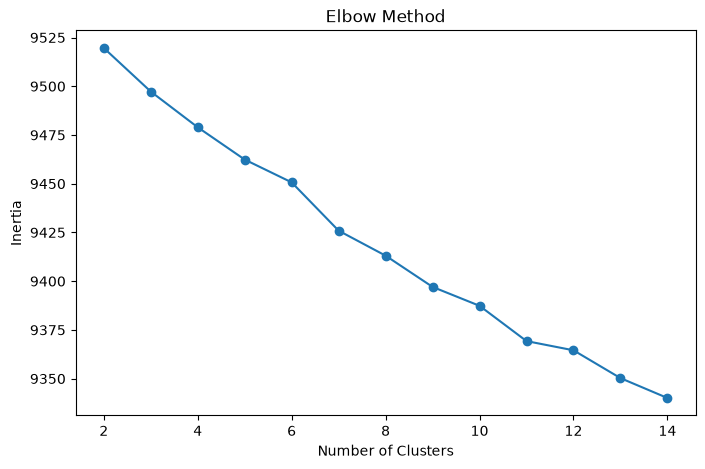

In [8]:
inertia = []

for k in range(2,15):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    inertia.append(kmeans.inertia_)



plt.figure(figsize=(8,5))

plt.plot(range(2,15), inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [9]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)


df['cluster'] = kmeans.fit_predict(X)


df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,text,clean_text,cluster
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...,The Grand Seduction A small fishing village mu...,grand seduction small fishing village must pro...,0
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...,Take Care Good Night A Metro Family decides to...,take care good night metro family decides figh...,2
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...,Secrets of Deception After a man discovers his...,secret deception man discovers wife cheating n...,2
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her ...",Pink: Staying True Pink breaks the mold once a...,pink staying true pink break mold bringing car...,0
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...,Monster Maker Teenage Matt Banting wants to wo...,monster maker teenage matt banting want work f...,2


In [10]:
score = silhouette_score(
    X,
    df['cluster']
)

print("Silhouette Score:", score)

Silhouette Score: 0.0030734544346393096


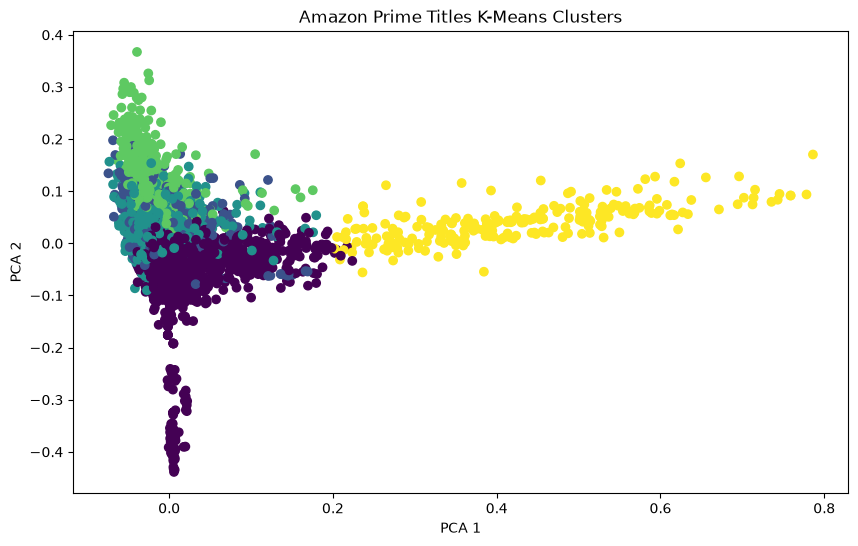

In [11]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X.toarray()
)


plt.figure(figsize=(10,6))


plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['cluster']
)


plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.title("Amazon Prime Titles K-Means Clusters")

plt.show()

In [12]:
for cluster in range(5):

    print("\n\nCLUSTER:", cluster)

    print(
        df[df['cluster']==cluster]['title']
        .head(10)
        .to_list()
    )



CLUSTER: 0
['The Grand Seduction', 'Pink: Staying True', 'Grease Live!', 'Global Meltdown', 'Take Care', 'The Night Eats The World', 'Zoombies', 'Zoo Babies', 'Zoë Coombs Marr: Bossy Bottom', 'Zoboomafoo']


CLUSTER: 1
['Living With Dinosaurs', 'Hired Gun', 'Resilencia', 'Elon Musk: The Real Life Iron Man', "Summer '03", 'Yoga to Break Any Habit', 'Yearly Departed', 'Wonders of Mexico', 'Wizard of Loneliness, The', 'William Lee Martin: Standing in the Middle']


CLUSTER: 2
['Take Care Good Night', 'Secrets of Deception', 'Monster Maker', "David's Mother", 'Forest Fairies', 'Young Lovers', 'Young Lions', 'X-Ray', 'Woman Of Desire', 'Woke Up Like This']


CLUSTER: 3
['Zoe', 'Zahara: The Return', 'Young Love (at the Sun Factory)', 'Young Love (at Bowery Ballroom)', 'You, Me and Him', 'Wrangler: Anatomy of an Icon', 'Wotakoi: Love is Hard for Otaku', 'Words On Bathroom Walls', 'Where Love Found Me', 'When the Lights Go On Again']


CLUSTER: 4
['Wonderful Nursery Rhymes with Mia - Little 

In [13]:
df.to_csv(
    "amazon_prime_clustered.csv",
    index=False
)